# 04_backtest_grid.py 결과 확인

`data/backtest_results`에 저장된 백테스트 결과를 확인한다.
- 전략별 최종 성과(누적수익률/MDD/샤프비율) 상위·하위 랭킹
- monthly vs quarterly 리밸런싱 주기별 비교
- 특정 전략 하나의 구간별 수익률 시계열 확인
- 종목 보유 수(held_count) 추이로 스크리닝이 정상 작동했는지 확인
- portfolio_size(n10~n300)별 누적수익률 비교 (보유 종목 수가 성과에 미치는 영향, 조건 평균)
- PER/PBR/배당수익률 조건별 n10~n300 수익률 (표/히트맵/시계열로 조건x n을 함께 비교)

In [2]:
# Jupyter 컨테이너(jupyter/pyspark-notebook 이미지)에는 한글 폰트가 없어 그래프의 한글이
# 네모(tofu)로 깨진다. 폰트가 이미 설치돼 있으면 apt-get을 건너뛴다 - apt-get은 root 권한이
# 필요한데 Jupyter 커널이 비root(jovyan)로 뜨는 경우 apt-get update 자체가 실패하므로
# (2026-08-01 실측 확인), 폰트가 이미 있으면 호출하지 않는다.
import subprocess
import matplotlib.font_manager as fm

def _has_nanum() -> bool:
    fm.fontManager = fm._load_fontmanager(try_read_cache=False)
    return any("Nanum" in f.name for f in fm.fontManager.ttflist)

if not _has_nanum():
    subprocess.run(
        "apt-get update -qq && apt-get install -y -qq fonts-nanum && fc-cache -fv",
        shell=True, check=True, capture_output=True,
    )

import matplotlib.pyplot as plt

# matplotlib은 시작 시점에 폰트 목록을 캐시해두므로, 방금 설치한 폰트는 fontManager.ttflist에
# 아직 안 잡힌다(실측: 재실행해도 빈 리스트). _load_fontmanager(try_read_cache=False)로 캐시를
# 무시하고 시스템 폰트를 다시 스캔해야 나눔 폰트가 인식된다.
fm.fontManager = fm._load_fontmanager(try_read_cache=False)

nanum_fonts = [f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
if not nanum_fonts:
    raise RuntimeError("나눔 폰트 설치/인식 실패 - fc-list와 fontManager.ttflist를 직접 확인할 것")
plt.rcParams["font.family"] = nanum_fonts[0]
plt.rcParams["axes.unicode_minus"] = False  # 나눔 폰트는 유니코드 마이너스(-) 글리프가 없어 깨짐 - ASCII(-)로 대체
print(f"사용 폰트: {plt.rcParams['font.family']}")

사용 폰트: ['NanumSquareRound']


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.master("spark://spark-master:7077").appName("check_backtest").getOrCreate()

# 2026-07-31 벡터화(계획 트리 폭발 수정) 이후 첫 성공 실행 결과. 룩어헤드 수정 반영 + n=300 포함.
# 이전 backtest_results/(07-30 15:44, n=20 포함, 룩어헤드 수정 이전)와는 값이 다르므로 비교 대상이 아니다.
RESULT_DIR = "/opt/spark-apps/data/backtest_results_kospi_n300"

summary = spark.read.parquet(f"{RESULT_DIR}/summary")
period = spark.read.parquet(f"{RESULT_DIR}/period_returns")

print(f"전략 수(summary): {summary.count()}")
print(f"구간 수익률 행 수(period_returns): {period.count()}")
summary.printSchema()

전략 수(summary): 1000
구간 수익률 행 수(period_returns): 22775
root
 |-- name: string (nullable = true)
 |-- final_cum_return: double (nullable = true)
 |-- mdd: double (nullable = true)
 |-- avg_period_return: double (nullable = true)
 |-- stddev_period_return: double (nullable = true)
 |-- sharpe_ratio: double (nullable = true)



## 1. 누적수익률 상위 20개 전략

In [4]:
top20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.desc("final_cum_return")).limit(20).toPandas()
top20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per20_pbr1.2_dy3.0_monthly_n300,0.587341,-0.173879,0.015428,0.067569,0.228322
1,per20_pbr1.0_dy3.0_monthly_n300,0.584718,-0.182212,0.015390,0.067763,0.227120
2,per20_pbr1.2_dy3.0_monthly_n100,0.579329,-0.173475,0.015316,0.068128,0.224816
3,per20_pbr1.5_dy3.0_monthly_n100,0.573131,-0.166162,0.015168,0.067653,0.224209
4,per20_pbr1.0_dy3.0_monthly_n100,0.570100,-0.180072,0.015145,0.068148,0.222243
5,per20_pbr2.0_dy3.0_monthly_n100,0.567466,-0.168754,0.015037,0.067257,0.223582
6,per20_pbr1.5_dy3.0_monthly_n300,0.558468,-0.170754,0.014848,0.066852,0.222095
7,per20_pbr2.0_dy3.0_monthly_n300,0.550419,-0.171473,0.014645,0.066060,0.221698
8,per20_pbr0.8_dy3.0_monthly_n300,0.540123,-0.175919,0.014627,0.068705,0.212890
9,per15_pbr1.2_dy3.0_monthly_n100,0.533011,-0.176082,0.014382,0.067008,0.214629


## 2. 누적수익률 하위 20개 전략

In [5]:
bottom20 = summary.filter(F.col("final_cum_return").isNotNull()) \
    .orderBy(F.asc("final_cum_return")).limit(20).toPandas()
bottom20

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per10_pbr0.8_dynone_monthly_n10,-0.128790,-0.397455,-0.000826,0.081176,-0.010174
1,per12_pbr0.8_dynone_monthly_n10,-0.128790,-0.397455,-0.000826,0.081176,-0.010174
2,per8_pbr0.8_dynone_monthly_n10,-0.128790,-0.397455,-0.000826,0.081176,-0.010174
3,per10_pbr1.5_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743
4,per10_pbr2.0_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743
5,per12_pbr1.5_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743
6,per12_pbr2.0_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743
7,per15_pbr1.5_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743
8,per15_pbr2.0_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743
9,per20_pbr1.5_dy1.0_quarterly_n30,-0.117093,-0.334742,-0.006940,0.098108,-0.070743


## 3. 샤프비율 상위 20개 전략 (수익률 대비 위험조정 성과)

In [6]:
top_sharpe = summary.filter(F.col("sharpe_ratio").isNotNull()) \
    .orderBy(F.desc("sharpe_ratio")).limit(20).toPandas()
top_sharpe

,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio
0,per15_pbr2.0_dy3.0_quarterly_n300,0.209814,-0.177279,0.020694,0.087193,0.237338
1,per15_pbr2.0_dy3.0_quarterly_n100,0.204929,-0.182606,0.020348,0.087497,0.232558
2,per20_pbr1.2_dy3.0_monthly_n300,0.587341,-0.173879,0.015428,0.067569,0.228322
3,per20_pbr1.0_dy3.0_monthly_n300,0.584718,-0.182212,0.015390,0.067763,0.227120
4,per20_pbr1.2_dy3.0_monthly_n100,0.579329,-0.173475,0.015316,0.068128,0.224816
5,per20_pbr1.5_dy3.0_monthly_n100,0.573131,-0.166162,0.015168,0.067653,0.224209
6,per20_pbr2.0_dy3.0_monthly_n100,0.567466,-0.168754,0.015037,0.067257,0.223582
7,per20_pbr1.0_dy3.0_monthly_n100,0.570100,-0.180072,0.015145,0.068148,0.222243
8,per20_pbr1.5_dy3.0_monthly_n300,0.558468,-0.170754,0.014848,0.066852,0.222095
9,per20_pbr2.0_dy3.0_monthly_n300,0.550419,-0.171473,0.014645,0.066060,0.221698


## 4. monthly vs quarterly 리밸런싱 주기 비교
전략 이름에서 rebalance 종류를 뽑아 그룹별 평균 성과를 비교한다.
(이름 규칙: `per{PER상한}_pbr{PBR상한}_dy{배당하한}_{rebalance}_n{보유종목수}`)

In [7]:
with_rebalance = summary.withColumn(
    "rebalance",
    F.when(F.col("name").contains("_monthly_"), "monthly").otherwise("quarterly"),
)

with_rebalance.groupBy("rebalance").agg(
    F.avg("final_cum_return").alias("avg_final_cum_return"),
    F.avg("mdd").alias("avg_mdd"),
    F.avg("sharpe_ratio").alias("avg_sharpe_ratio"),
    F.count("*").alias("strategy_count"),
).toPandas()

,rebalance,avg_final_cum_return,avg_mdd,avg_sharpe_ratio,strategy_count
0,monthly,0.160434,-0.274237,0.093427,500
1,quarterly,0.034442,-0.265193,0.075085,500


## 5. 특정 전략 하나의 구간별 수익률 시계열
이름을 바꿔서 원하는 전략의 리밸런싱 구간별 수익률 흐름을 확인할 수 있다.

In [8]:
target_strategy = "per8_pbr1.2_dynone_monthly_n100"

one_strategy = period.filter(F.col("name") == target_strategy) \
    .orderBy("period_start").toPandas()
one_strategy

,name,period_start,period_end,period_return,held_count
0,per8_pbr1.2_dynone_monthly_n100,20210131,20210228,0.030303,1
1,per8_pbr1.2_dynone_monthly_n100,20210228,20210331,0.030000,2
2,per8_pbr1.2_dynone_monthly_n100,20210331,20210430,0.094104,74
3,per8_pbr1.2_dynone_monthly_n100,20210430,20210531,0.056743,71
4,per8_pbr1.2_dynone_monthly_n100,20210531,20210630,0.020745,67
5,per8_pbr1.2_dynone_monthly_n100,20210630,20210731,-0.028112,67
6,per8_pbr1.2_dynone_monthly_n100,20210731,20210831,-0.045575,67
7,per8_pbr1.2_dynone_monthly_n100,20210831,20210930,0.003828,75
8,per8_pbr1.2_dynone_monthly_n100,20210930,20211031,-0.030337,78
9,per8_pbr1.2_dynone_monthly_n100,20211031,20211130,-0.117621,81


### 누적수익률 곡선 그래프

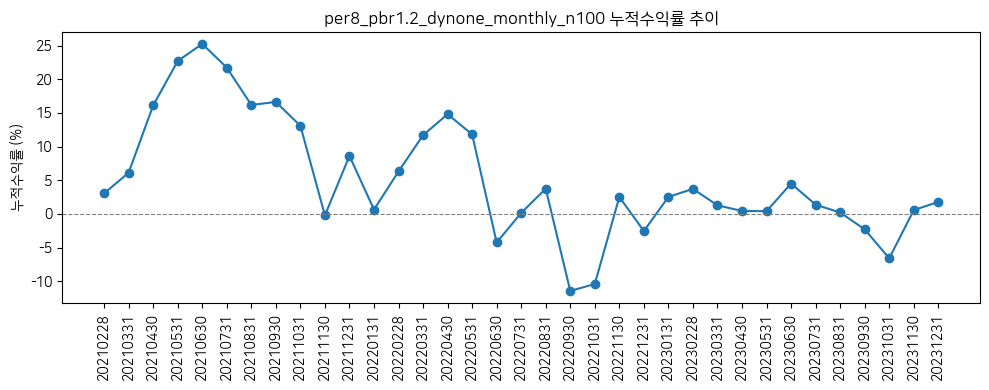

In [9]:
one_strategy["cum_return"] = (1 + one_strategy["period_return"]).cumprod() - 1

plt.figure(figsize=(10, 4))
plt.plot(one_strategy["period_end"], one_strategy["cum_return"] * 100, marker="o")
plt.xticks(rotation=90)
plt.title(f"{target_strategy} 누적수익률 추이")
plt.ylabel("누적수익률 (%)")  # cum_return은 0.5=원금의 50% 증가를 뜻하는 비율값이라 *100으로 % 표시
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # 원금(0%) 기준선 - 이 선 위/아래로 손익 방향이 갈린다
plt.tight_layout()
plt.show()

## 6. 종목 보유 수(held_count) 추이
시점이 갈수록 그 시점 이전에 공시된 사업보고서가 누적되므로, 초반 시점(2021년 초)은 held_count가
적고 뒤로 갈수록 늘어나는 것이 정상이다 (룩어헤드 바이어스 방지 로직이 실제로 작동하는 증거).

In [10]:
held_trend = period.filter(F.col("name") == target_strategy) \
    .select("period_start", "held_count").orderBy("period_start").toPandas()
held_trend

,period_start,held_count
0,20210131,1
1,20210228,2
2,20210331,74
3,20210430,71
4,20210531,67
5,20210630,67
6,20210731,67
7,20210831,75
8,20210930,78
9,20211031,81


## 7. 이상치 확인: final_cum_return이 null인 전략
구간 수익률 계산 자체가 안 된 전략(예: 어느 시점에도 조건을 만족하는 종목이 없었던 전략)이 있는지 확인.

In [11]:
null_result = summary.filter(F.col("final_cum_return").isNull())
print(f"결과 없는 전략 수: {null_result.count()}")
null_result.toPandas()

결과 없는 전략 수: 0


,name,final_cum_return,mdd,avg_period_return,stddev_period_return,sharpe_ratio


## 8. portfolio_size(n10~n300)별 누적수익률 비교

`conf/strategies.yaml`의 `PORTFOLIO_SIZE` 후보(10/30/50/100/300)마다, 같은 조건(PER/PBR/배당수익률)의
나머지 전략들을 평균내 대표 누적수익률 곡선을 하나씩 그린다. "조건 자체가 시장 평균 대비 선별
효과가 있는가"를 보려는 게 아니라 - n이 작을수록(더 엄격하게 소수만 고를수록) 수익률/변동성이
어떻게 달라지는지, 즉 **보유 종목 수가 성과에 미치는 영향**을 눈으로 확인하는 목적이다.

`period`(구간별 수익률)를 직접 쓰는 이유: `summary.final_cum_return`은 전략별 값 하나뿐이라
시계열 그래프를 그릴 수 없다. `period_return`을 시간순 복리 누적(`summarize_performance`의
`cum_return` 계산과 동일한 방식)해야 곡선이 나온다.

In [12]:
# name 끝의 _n{숫자}에서 portfolio_size를 뽑는다. conf/generate_strategies.py의 strategy_name()이
# f"..._n{portfolio_size}" 형식으로 짓는 규칙과 정확히 일치해야 한다.
with_size = period.withColumn(
    "portfolio_size", F.regexp_extract(F.col("name"), r"_n(\d+)$", 1).cast("int")
)

# 같은 (portfolio_size, period_start/end) 조합에 속한 모든 전략(PER/PBR/배당/rebalance 조합 전체)의
# 구간수익률을 평균낸다 - "n마다 대표 곡선 하나"를 만들기 위함이다.
size_period_avg = with_size.groupBy("portfolio_size", "period_start", "period_end").agg(
    F.avg("period_return").alias("avg_period_return")
).orderBy("portfolio_size", "period_start").toPandas()

print(f"portfolio_size 후보: {sorted(size_period_avg['portfolio_size'].unique())}")
size_period_avg.head()

portfolio_size 후보: [10, 30, 50, 100, 300]


,portfolio_size,period_start,period_end,avg_period_return
0,10,20210131,20210228,0.014233
1,10,20210228,20210331,0.120030
2,10,20210331,20210430,0.087207
3,10,20210331,20210630,0.206978
4,10,20210430,20210531,0.066772


**monthly만 따로 본다.** portfolio_size 그룹 안에는 monthly(구간 35개)와 quarterly(구간 11개)
전략이 섞여 있는데, 리밸런싱 주기가 다르면 구간 하나의 길이(1개월치 vs 3개월치 수익률)가 달라
평균을 그대로 합치면 왜곡된다. 위 4번 섹션에서 이미 monthly/quarterly 성과 자체가 다르다는 걸
확인했으므로, 이 그래프는 리밸런싱 주기를 monthly로 고정해 portfolio_size 하나만 변수로 남긴다.

In [13]:
monthly_with_size = with_size.filter(F.col("name").contains("_monthly_"))

monthly_size_avg = monthly_with_size.groupBy("portfolio_size", "period_start", "period_end").agg(
    F.avg("period_return").alias("avg_period_return")
).orderBy("portfolio_size", "period_start").toPandas()

# 시간순 복리 누적 - summarize_performance()의 cum_return 계산(F.exp(F.sum(F.log(r+1))) - 1)과
# 같은 방식을 pandas로 재현한다. portfolio_size별로 따로 누적해야 하므로 groupby 후 cumprod.
monthly_size_avg["cum_return"] = (
    monthly_size_avg.groupby("portfolio_size")["avg_period_return"]
    .transform(lambda s: (1 + s).cumprod() - 1)
)
monthly_size_avg.head()

,portfolio_size,period_start,period_end,avg_period_return,cum_return
0,10,20210131,20210228,0.014233,0.014233
1,10,20210228,20210331,0.120030,0.135971
2,10,20210331,20210430,0.087207,0.235036
3,10,20210430,20210531,0.066772,0.317501
4,10,20210531,20210630,0.023375,0.348297


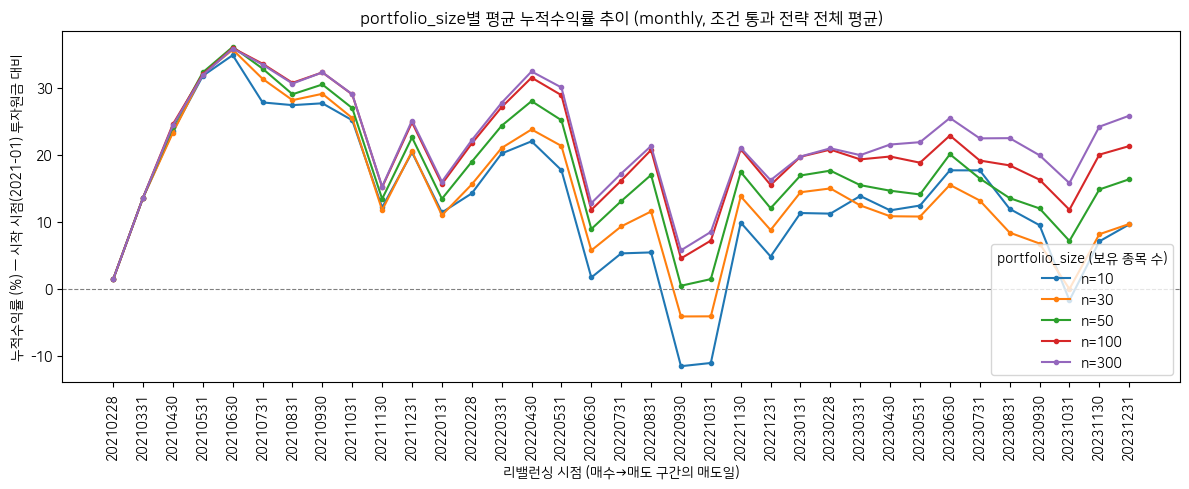

In [14]:
plt.figure(figsize=(12, 5))
for size in sorted(monthly_size_avg["portfolio_size"].unique()):
    subset = monthly_size_avg[monthly_size_avg["portfolio_size"] == size]
    plt.plot(subset["period_end"], subset["cum_return"] * 100, marker="o", markersize=3, label=f"n={size}")

plt.xticks(rotation=90)
plt.legend(title="portfolio_size (보유 종목 수)")
plt.title("portfolio_size별 평균 누적수익률 추이 (monthly, 조건 통과 전략 전체 평균)")
# cum_return은 "원금 대비 몇 배 불었나"를 나타내는 비율(0.6 = +60%)이라 *100으로 %를 명시해야 읽힌다.
plt.ylabel("누적수익률 (%) — 시작 시점(2021-01) 투자원금 대비")
plt.xlabel("리밸런싱 시점 (매수→매도 구간의 매도일)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # 원금(0%) 기준선
plt.tight_layout()
plt.show()

In [15]:
# 그래프의 마지막 지점(최종 누적수익률)만 뽑아 %로도 비교한다.
final_by_size = (
    monthly_size_avg.sort_values("period_end")
    .groupby("portfolio_size")
    .tail(1)[["portfolio_size", "period_end", "cum_return"]]
    .sort_values("portfolio_size")
    .reset_index(drop=True)
)
final_by_size["누적수익률(%)"] = (final_by_size["cum_return"] * 100).round(1)
final_by_size

,portfolio_size,period_end,cum_return,누적수익률(%)
0,10,20231231,0.095916,9.6
1,30,20231231,0.096546,9.7
2,50,20231231,0.163240,16.3
3,100,20231231,0.212722,21.3
4,300,20231231,0.257990,25.8


## 9. PER/PBR/배당수익률 조건별 n10~n300 수익률

위 8번 그래프는 `portfolio_size`로만 묶고 PER/PBR/배당 조건은 평균으로 뭉갰다 - "n=10이 좋다"는
결과가 (a) 어떤 조건이든 n을 줄이면 대체로 좋아진다는 뜻인지, (b) 극소수 조합이 평균을 끌어올린
것뿐인지 구분이 안 된다. 이 섹션은 조건(PER/PBR/배당/리밸런싱)을 살려서 조합별로 n10~n300 수익률을
직접 비교한다.

`name`을 `per{PER}_pbr{PBR}_dy{배당 or none}_{rebalance}_n{size}` 규칙(conf/generate_strategies.py의
`strategy_name()`)에 맞춰 정규식으로 분해한다.

In [16]:
# name 하나를 (조건, portfolio_size)로 완전히 분해한다. strategy_name()의 dy_label 규칙(None -> "none")과
# 정확히 맞춰야 하므로 정규식 그룹으로 pbr의 소수점(예: 0.8)까지 포함해 잘라낸다.
pattern = r"^per(\d+)_pbr([\d.]+)_dy(none|[\d.]+)_(monthly|quarterly)_n(\d+)$"
parsed = summary.select(
    "name", "final_cum_return", "mdd", "sharpe_ratio",
    F.regexp_extract("name", pattern, 1).cast("int").alias("per_max"),
    F.regexp_extract("name", pattern, 2).cast("double").alias("pbr_max"),
    F.regexp_extract("name", pattern, 3).alias("dy_label"),
    F.regexp_extract("name", pattern, 4).alias("rebalance"),
    F.regexp_extract("name", pattern, 5).cast("int").alias("portfolio_size"),
)

# 파싱이 깨진 행(정규식이 안 맞아 컬럼이 전부 빈 문자열/null)이 있으면 뒤 분석이 조용히 틀어지므로 먼저 검증한다.
unparsed = parsed.filter(F.col("per_max").isNull())
unparsed_count = unparsed.count()
print(f"파싱 실패 행: {unparsed_count}건 {'(정상)' if unparsed_count == 0 else '(name 규칙 확인 필요)'}")

# 조건(PER/PBR/배당/리밸런싱) 하나가 200개 조건 조합 중 하나를 가리키는 라벨을 만든다.
parsed = parsed.withColumn(
    "condition", F.concat_ws("_", F.col("per_max"), F.col("pbr_max"), F.col("dy_label"), F.col("rebalance"))
)

condition_by_size = parsed.select(
    "condition", "portfolio_size", "final_cum_return"
).toPandas()
print(f"조건 조합 수: {condition_by_size['condition'].nunique()}개 x portfolio_size {sorted(condition_by_size['portfolio_size'].unique())}")

# condition을 행, portfolio_size를 열로 피벗 - "9-1. 전체 표"의 기반이 되는 넓은 형태.
pivot = condition_by_size.pivot(index="condition", columns="portfolio_size", values="final_cum_return")
pivot.columns = [f"n{c}" for c in pivot.columns]
pivot = (pivot * 100).round(1)  # cum_return은 비율값(0.6=60%)이라 %로 통일해서 표시
pivot.head()

파싱 실패 행: 0건 (정상)
조건 조합 수: 200개 x portfolio_size [10, 30, 50, 100, 300]


,n10,n30,n50,n100,n300
condition,,,,,
10_0.8_1.0_monthly,12.5,1.2,9.6,9.1,13.2
10_0.8_1.0_quarterly,8.3,-8.5,3.3,4.2,6.4
10_0.8_2.0_monthly,10.2,0.5,9.9,10.4,13.0
10_0.8_2.0_quarterly,14.1,-4.0,2.8,5.1,7.1
10_0.8_3.0_monthly,5.8,13.2,14.5,18.5,18.8


### 9-1. 전체 표 (조건 조합 x n, 200행)
`n10` 열 기준으로 내림차순 정렬 - n이 가장 작을 때(가장 엄격한 선별) 어떤 조건 조합이 잘 되는지부터 본다.

In [17]:
n_cols = [c for c in pivot.columns if c.startswith("n")]
pivot_sorted = pivot.sort_values("n10", ascending=False)
pivot_sorted

,n10,n30,n50,n100,n300
condition,,,,,
15_0.8_1.0_monthly,32.7,19.4,29.2,35.2,41.0
20_0.8_1.0_monthly,32.2,18.9,28.7,34.8,41.0
15_0.8_2.0_monthly,30.0,18.6,34.2,36.1,41.2
20_0.8_2.0_monthly,30.0,18.6,33.6,37.4,42.6
15_1.0_1.0_monthly,29.9,20.3,26.2,37.1,42.7
...,...,...,...,...,...
10_1.0_none_monthly,-10.1,-7.1,-1.1,5.7,12.1
12_1.0_none_monthly,-10.1,-7.1,-1.1,7.5,17.4
10_0.8_none_monthly,-12.9,-8.1,-2.2,6.4,13.0


### 9-2. 히트맵 (상위 20개 조건 x n)
200개 조건을 전부 넣으면 라벨이 겹쳐 안 보이므로, n10 기준 상위 20개 조건만 추려 색상으로 비교한다.
색이 진할수록(빨강) 고수익, 연할수록(파랑) 저수익 - 어떤 조건 x n 조합이 실제로 두드러지는지 한눈에 본다.

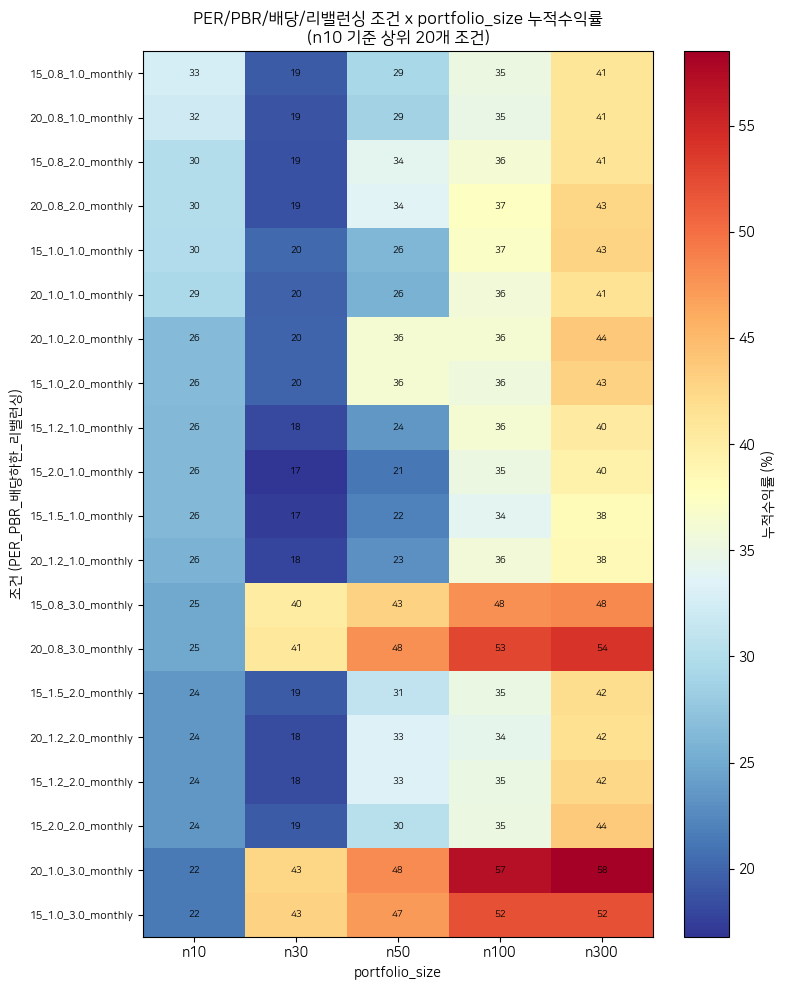

In [18]:
import numpy as np

top20_pivot = pivot_sorted.head(20)[n_cols]

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(top20_pivot.values, cmap="RdYlBu_r", aspect="auto")

ax.set_xticks(range(len(n_cols)))
ax.set_xticklabels(n_cols)
ax.set_yticks(range(len(top20_pivot)))
ax.set_yticklabels(top20_pivot.index, fontsize=8)

# 칸마다 실제 값을 숫자로 함께 적어 색만으로 판단하지 않게 한다.
for i in range(top20_pivot.shape[0]):
    for j in range(top20_pivot.shape[1]):
        val = top20_pivot.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                color="black", fontsize=7)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("누적수익률 (%)")
ax.set_title("PER/PBR/배당/리밸런싱 조건 x portfolio_size 누적수익률\n(n10 기준 상위 20개 조건)")
ax.set_xlabel("portfolio_size")
ax.set_ylabel("조건 (PER_PBR_배당하한_리밸런싱)")
plt.tight_layout()
plt.show()

### 9-3. 상위 조건 3개의 n10~n300 누적수익률 시계열
표·히트맵은 "최종 값"만 보여준다. 여기서는 상위 조건 몇 개를 골라 8번 섹션과 같은 방식(구간수익률
시간순 복리 누적)으로 시계열 곡선을 그린다 - 최종 수익률이 같아도 도달 경로(변동성, 중간 낙폭)가
다를 수 있으므로 곡선 모양까지 봐야 판단이 완전해진다.

In [19]:
# n10 기준 상위 3개 조건을 고른다 (9-1 표와 동일 정렬 기준).
top3_conditions = pivot_sorted.head(3).index.tolist()
print("상위 3개 조건:", top3_conditions)

# condition 라벨("per15_1.2_none_monthly")을 name 접두어("per15_pbr1.2_dynone_monthly_")로 되돌린다.
# strategy_name()의 f"per{per}_pbr{pbr}_dy{dy}_{rebalance}_n{size}" 규칙을 그대로 뒤집는 것.
def condition_to_name_prefix(cond: str) -> str:
    per_max, pbr_max, dy_label, rebalance = cond.split("_")
    return f"per{per_max}_pbr{pbr_max}_dy{dy_label}_{rebalance}_n"

top3_prefixes = [condition_to_name_prefix(c) for c in top3_conditions]

condition_period = period.filter(
    F.regexp_extract(F.col("name"), r"^(.+_n)\d+$", 1).isin(top3_prefixes)
).withColumn(
    "portfolio_size", F.regexp_extract(F.col("name"), r"_n(\d+)$", 1).cast("int")
).withColumn(
    "condition_label", F.regexp_extract(F.col("name"), r"^(.+)_n\d+$", 1)
)

condition_period_pd = condition_period.groupBy(
    "condition_label", "portfolio_size", "period_start", "period_end"
).agg(F.avg("period_return").alias("period_return")).orderBy(
    "condition_label", "portfolio_size", "period_start"
).toPandas()

condition_period_pd["cum_return"] = (
    condition_period_pd.groupby(["condition_label", "portfolio_size"])["period_return"]
    .transform(lambda s: (1 + s).cumprod() - 1)
)
condition_period_pd.head()

상위 3개 조건: ['15_0.8_1.0_monthly', '20_0.8_1.0_monthly', '15_0.8_2.0_monthly']


,condition_label,portfolio_size,period_start,period_end,period_return,cum_return
0,per15_pbr0.8_dy1.0_monthly,10,20210131,20210228,0.001305,0.001305
1,per15_pbr0.8_dy1.0_monthly,10,20210228,20210331,0.248580,0.250210
2,per15_pbr0.8_dy1.0_monthly,10,20210331,20210430,0.095215,0.369248
3,per15_pbr0.8_dy1.0_monthly,10,20210430,20210531,0.046920,0.433493
4,per15_pbr0.8_dy1.0_monthly,10,20210531,20210630,0.021487,0.464294


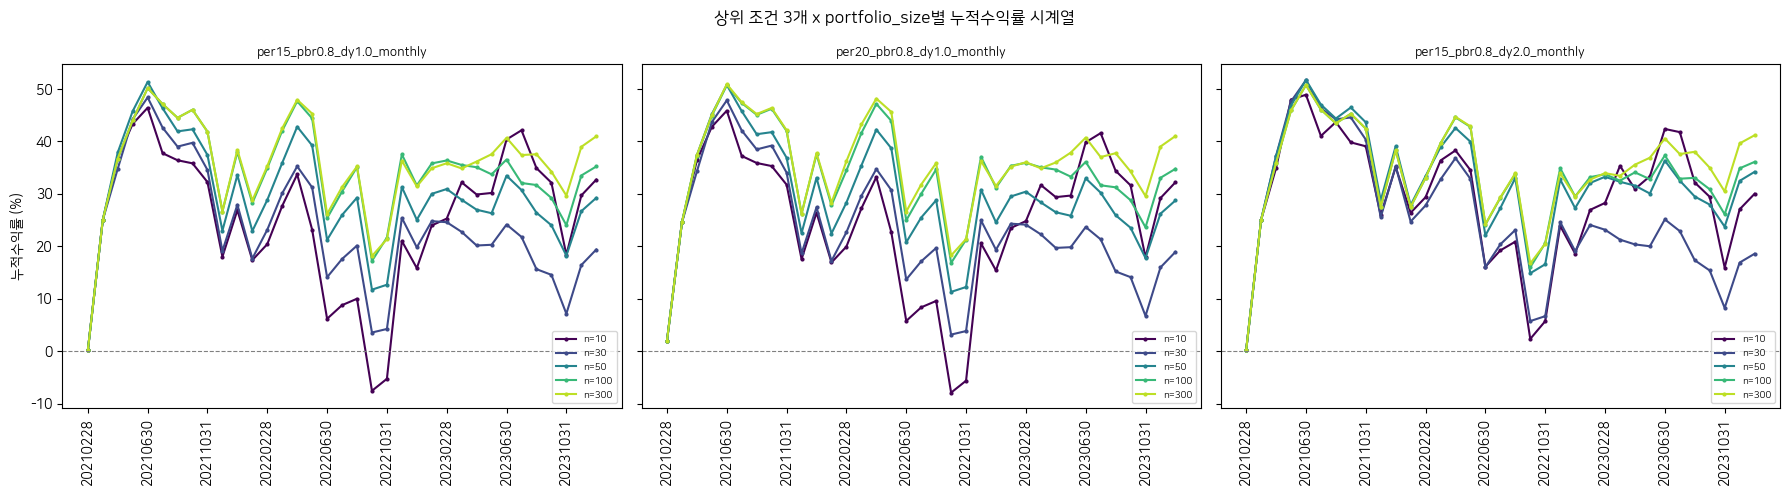

In [20]:
fig, axes = plt.subplots(1, len(top3_conditions), figsize=(18, 5), sharey=True)
if len(top3_conditions) == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 0.9, 5))  # n10~n300 5단계를 밝기로 구분

for ax, cond in zip(axes, top3_conditions):
    label = condition_to_name_prefix(cond).rstrip("_n")
    subset = condition_period_pd[condition_period_pd["condition_label"] == label]
    for color, size in zip(colors, sorted(subset["portfolio_size"].unique())):
        line = subset[subset["portfolio_size"] == size]
        ax.plot(line["period_end"], line["cum_return"] * 100, marker="o", markersize=2,
                color=color, label=f"n={size}")
    ax.set_title(label, fontsize=9)
    ax.set_xticks(ax.get_xticks()[::4])  # 라벨이 15개 서브플롯 x 35시점이라 겹치므로 4개마다만 표시
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=7)

axes[0].set_ylabel("누적수익률 (%)")
fig.suptitle("상위 조건 3개 x portfolio_size별 누적수익률 시계열")
plt.tight_layout()
plt.show()

In [21]:
spark.stop()

## 10. 결과 해석 (2026-08-01 정리)

이 노트북(PER/PBR/배당수익률 문턱값 그리드, 1,000개 전략, 2021~2023 KOSPI)의 실행 결과에서
확인된 사실과 추론.

### 알아낸 사실

1. **리밸런싱 주기 자체가 조건(PER/PBR/배당)보다 성과에 더 크게 작용했다.**
   섹션 4: monthly 평균 누적수익률 +16.0%(500개 전략 평균) vs quarterly 평균 +3.4%(500개 전략
   평균). 조건을 아무리 조여도 quarterly 그룹 전체가 monthly 그룹 전체보다 체계적으로 낮았다 —
   "리밸런싱을 자주 할수록 하락 국면에서 손절/재편입 기회가 늘어 손실을 덜 키운다"는 가설과
   부합한다(2021~2023이 전반적 하락/횡보장이었다는 사실과 결합해서 해석).

2. **portfolio_size(n)를 늘릴수록 성과가 단조롭게 개선됐다** (섹션 8, "그래프의 마지막 지점").
   monthly 전체 평균 기준 n10 +9.6% → n30 +9.7% → n50 +16.3% → n100 +21.3% → n300 +25.8%로
   거의 단조 증가했다. 이건 "종목을 더 많이 담을수록 무조건 좋다"는 뜻이 아니라, **n이 작을수록
   소수 종목의 개별 이상치에 성과가 크게 흔들린다**는 뜻이다(분산 효과). 실측된 사례: 종목
   101140이 2023-10-23 하루 만에 +1900% 급등한 게 n10 계열 성과를 크게 부풀린 원인 중 하나로
   이미 확인돼 있다(위 "백테스트 결과 해석" 섹션 참고). n10/n30이 n50보다 오히려 낮게 나온 것도
   (9.6%, 9.7% vs 16.3%) 소수 표본의 변동성이 여전히 크다는 정황이다.

3. **배당수익률 하한(dy) 조건이 있는 전략이 없는 전략보다 뚜렷하게 우수했다** (섹션 1, 2, 9-1).
   최고 성과 상위 20개(섹션 1)가 전부 `dy3.0`(배당수익률 3% 이상) 조건이었고, 하위 20개(섹션
   2)에는 `dynone`(배당 조건 없음)이 다수 섞여 있었다. 섹션 9-1 표에서도 `dynone` 계열이
   전반적으로 하위권에 몰려 있다.

4. **PER/PBR 상한 자체는 dy·n·rebalance보다 성과 차이에 덜 기여했다.**
   섹션 9-1 표를 보면 같은 dy/rebalance/n 안에서 PER 15~20, PBR 0.8~2.0 범위 안의 조합 간
   차이는 dy 유무나 n 크기가 만드는 차이보다 작았다. "저PER/저PBR일수록 무조건 좋다"는 단순
   가설은 이 표본에서 뚜렷하게 확인되지 않았다.

5. **샤프비율 1위(섹션 3)는 누적수익률 1위(섹션 1)와 다른 전략이었다.**
   `per15_pbr2.0_dy3.0_quarterly_n300`(누적 +21.0%, 샤프 0.237)이 샤프비율 1위인 반면,
   누적수익률 1위 `per20_pbr1.2_dy3.0_monthly_n300`(+58.7%)은 샤프 0.228로 근소하게 낮았다.
   quarterly가 monthly보다 평균 성과는 낮지만(위 1번) 일부 조건에서는 변동성 대비 안정성이
   더 좋을 수 있다는 뜻 — "monthly가 항상 전 지표에서 우월하다"는 결론까지는 못 간다.

### 이 표본에서만 유효한 해석 (일반화 경고)

- 위 결과는 **2021~2023년 KOSPI 3년 표본**에서 나온 사후 관찰이다. 이 기간 자체가 전체 종목
  평균 +0.6%, 중앙값 -21.8%인 하락장이었다는 게 이미 확인돼 있다(PROGRESS.md에도 기록됨).
  "배당 조건이 있는 게 유리했다"는 결과는 이 하락장에서 배당주가 상대적으로 방어적이었다는
  뜻이지, 상승장에서도 같은 패턴이 나온다는 보장은 없다.
- n이 클수록 좋아지는 패턴도 "분산이 하락장 방어에 유리했다"는 뜻이지, 표본 기간이 달라져도
  같은 기울기로 개선된다는 법칙이 아니다.
- 이 그리드 자체가 ValuePick 실제 서비스 로직(`Top100Service.scoreAll()`)과 무관한 별도
  실험이라는 점은 이미 위쪽(모듈 상단 설명)에 기록돼 있다 — 실제 서비스 로직을 재현한 점수
  방식 실험은 `check_04_backtest.ipynb` 참고.